# Tarea 4 — Vibraciones de una barra con resorte
IMEC 4001 — Matemáticas Aplicadas  
Universidad de los Andes · 2026-2

**Estudiante:** Luis Alejandro Rodríguez


In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq


## Ejercicio 2c

A partir de las condiciones de borde de los dos casos se obtiene la misma ecuación característica:

$$
(\beta L)\tan(\beta L)=\frac{kL}{EA}.
$$

Definiendo

$$
\lambda=\beta L,
\qquad
\gamma=\frac{kL}{EA},
$$

la ecuación que se debe resolver numéricamente es

$$
\boxed{F(\lambda)=\lambda\tan(\lambda)-\gamma=0}.
$$

Los valores de $\lambda_i$ corresponden a las raíces positivas de esta ecuación. Luego,

$$
\beta_i=\frac{\lambda_i}{L},
\qquad
\alpha_i=\beta_i^2.
$$


### Parámetros

Se consideran

$$
L=1,\qquad \rho=1,
$$

y los valores indicados para el parámetro $kL/(EA)$:

$$
\frac{kL}{EA}\in\{0.1,\,1,\,10\}.
$$


In [52]:
# Parámetros
L = 1
rho = 1

parametros = [0.1, 1, 10]
n_modos = 3

display(f"L = {L}")
display(f"rho = {rho}")
display(f"Parametros kL/(EA) = {parametros}")


'L = 1'

'rho = 1'

'Parametros kL/(EA) = [0.1, 1, 10]'

### Función característica

Para cada valor de $kL/(EA)$ se define

$$
F(\lambda)=\lambda\tan(\lambda)-\frac{kL}{EA}.
$$

Los primeros tres ceros positivos se buscan en los intervalos

$$
(0,\pi/2),\qquad
(\pi,3\pi/2),\qquad
(2\pi,5\pi/2).
$$

Se utiliza `brentq`, que encuentra una raíz de una función no lineal dentro de un intervalo donde la función cambia de signo.


In [53]:
def funcion(lambda_, gamma):
    return lambda_ * np.tan(lambda_) - gamma


def calcular_raices(gamma, n_modos=3):
    raices = []

    for n in range(n_modos):
        a = n * np.pi + 1e-10
        b = n * np.pi + np.pi / 2 - 1e-10

        raiz = brentq(funcion, a, b, args=(gamma,))
        raices.append(raiz)

    return np.array(raices)


In [54]:
# Cálculo de los tres primeros parámetros lambda_i

resultados = {}

for gamma in parametros:
    lambdas = calcular_raices(gamma, n_modos)
    resultados[gamma] = lambdas

    display(f"kL/(EA) = {gamma}")
    for i, value in enumerate(lambdas, start=1):
        display(f"lambda_{i} = {value:.6f}")


'kL/(EA) = 0.1'

'lambda_1 = 0.311053'

'lambda_2 = 3.173097'

'lambda_3 = 6.299059'

'kL/(EA) = 1'

...

'lambda_3 = 6.437298'

'kL/(EA) = 10'

'lambda_1 = 1.428870'

'lambda_2 = 4.305801'

'lambda_3 = 7.228110'

### Resultados

Los valores obtenidos numéricamente son los tres primeros ceros positivos de $F(\lambda)$ para cada valor del parámetro.


In [55]:
print(f"{'kL/(EA)':>10} {'lambda_1':>12} {'lambda_2':>12} {'lambda_3':>12}")
print("-" * 50)

for gamma in parametros:
    lambdas = resultados[gamma]
    print(
        f"{gamma:10.1f}"
        f"{lambdas[0]:12.6f}"
        f"{lambdas[1]:12.6f}"
        f"{lambdas[2]:12.6f}"
    )


   kL/(EA)     lambda_1     lambda_2     lambda_3
--------------------------------------------------
       0.1    0.311053    3.173097    6.299059
       1.0    0.860334    3.425618    6.437298
      10.0    1.428870    4.305801    7.228110


### Verificación gráfica

Se grafica $F(\lambda)$ para cada parámetro y se marcan las tres raíces encontradas por el algoritmo.


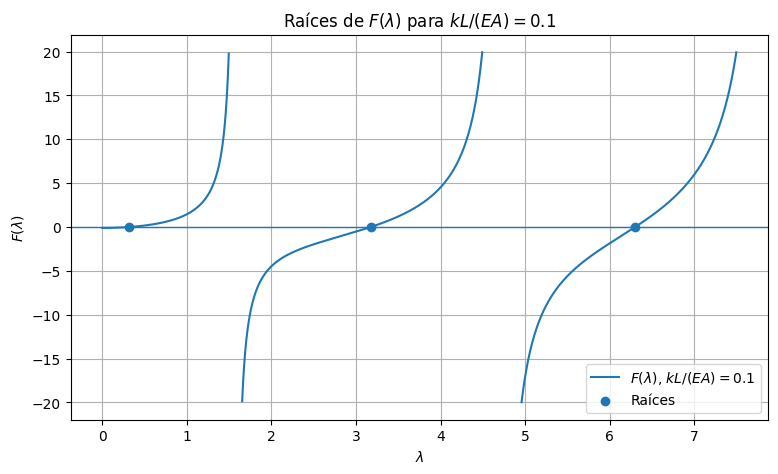

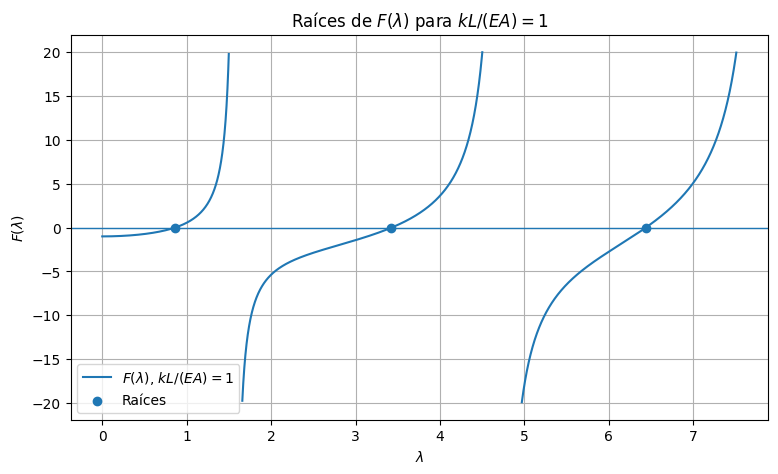

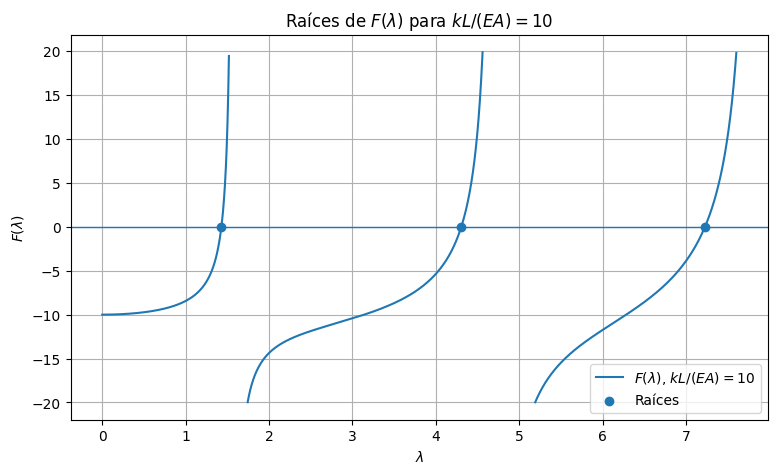

In [56]:
for gamma in parametros:
    lambdas = resultados[gamma]

    x_max = 2.5 * np.pi
    x = np.linspace(0, x_max, 5000)
    y = funcion(x, gamma)

    # Evitar valores muy grandes cerca de las asíntotas
    y[np.abs(y) > 20] = np.nan

    plt.figure(figsize=(9, 5))
    plt.plot(x, y, label=fr"$F(\lambda)$, $kL/(EA)={gamma}$")
    plt.axhline(0, linewidth=1)
    plt.scatter(
        lambdas,
        np.zeros_like(lambdas),
        zorder=3,
        label="Raíces"
    )

    plt.xlabel(r"$\lambda$")
    plt.ylabel(r"$F(\lambda)$")
    plt.title(fr"Raíces de $F(\lambda)$ para $kL/(EA)={gamma}$")
    plt.grid()
    plt.legend()
    plt.show()


### Cálculo de los autovalores $\alpha_i$

Como

$$
\lambda_i=\beta_iL,
$$

se tiene

$$
\beta_i=\frac{\lambda_i}{L}
$$

y por tanto

$$
\boxed{\alpha_i=\beta_i^2=\left(\frac{\lambda_i}{L}\right)^2}.
$$

Para $L=1$, resulta simplemente $\alpha_i=\lambda_i^2$.


In [57]:
# Autovalores alpha_i

for gamma in parametros:
    lambdas = resultados[gamma]
    alphas = (lambdas / L) ** 2

    display(f"kL/(EA) = {gamma}")
    for i, value in enumerate(alphas, start=1):
        display(f"alpha_{i} = {value:.6f}")


'kL/(EA) = 0.1'

'alpha_1 = 0.096754'

'alpha_2 = 10.068546'

'alpha_3 = 39.678149'

'kL/(EA) = 1'

...

'alpha_3 = 41.438808'

'kL/(EA) = 10'

'alpha_1 = 2.041670'

'alpha_2 = 18.539926'

'alpha_3 = 52.245571'

### Conclusión

El algoritmo numérico permite encontrar los parámetros $\lambda_i$ que satisfacen la ecuación característica. Los dos escenarios físicos tienen la misma ecuación característica, por lo que producen los mismos autovalores. La diferencia entre los casos aparece en la forma de los modos espaciales $u_i(x)$, debido a la ubicación del resorte y del extremo libre.


## Ejercicio 2e — Frecuencias naturales

Usando la pista del profesor,

$$
\tau=ct,
\qquad
c=\sqrt{\frac{E}{\rho}},
$$

la solución temporal es

$$
T_i(t)=\cos(\lambda_i ct).
$$

Comparando con

$$
T_i(t)=\cos(\omega_i t),
$$

se obtiene

$$
\boxed{\omega_i=\lambda_i\sqrt{\frac{E}{\rho}}}.
$$

Por tanto, se usan los $\lambda_i$ calculados en el ejercicio 2c.


In [58]:
# Parámetros para calcular las frecuencias
E = 1
c = np.sqrt(E / rho)

frecuencias = {}

for gamma in parametros:
    lambdas = resultados[gamma]
    omega = c * lambdas
    frecuencias[gamma] = omega

    display(f"kL/(EA) = {gamma}")
    for i, value in enumerate(omega, start=1):
        display(f"omega_{i} = {value:.6f} rad/s")


'kL/(EA) = 0.1'

'omega_1 = 0.311053 rad/s'

'omega_2 = 3.173097 rad/s'

'omega_3 = 6.299059 rad/s'

'kL/(EA) = 1'

...

'omega_3 = 6.437298 rad/s'

'kL/(EA) = 10'

'omega_1 = 1.428870 rad/s'

'omega_2 = 4.305801 rad/s'

'omega_3 = 7.228110 rad/s'

### Resultados

Como en este cálculo se toma $E=1$ y $\rho=1$,

$$
c=\sqrt{\frac{E}{\rho}}=1,
$$

por lo que numéricamente $\omega_i=\lambda_i$.

Los valores de $\omega_i$ son iguales para ambos escenarios, porque ambos tienen los mismos $\lambda_i$.


In [59]:
print(f"{'kL/(EA)':>10} {'omega_1':>14} {'omega_2':>14} {'omega_3':>14}")
print("-" * 56)

for gamma in parametros:
    omega = frecuencias[gamma]
    print(
        f"{gamma:10.1f}"
        f"{omega[0]:14.6f}"
        f"{omega[1]:14.6f}"
        f"{omega[2]:14.6f}"
    )


   kL/(EA)        omega_1        omega_2        omega_3
--------------------------------------------------------
       0.1      0.311053      3.173097      6.299059
       1.0      0.860334      3.425618      6.437298
      10.0      1.428870      4.305801      7.228110


## Ejercicio 2g)

Se parte de la condición inicial

$$

u_0(x)=u(x,0)=1.

$$

La solución modal se escribe como

$$

u(x,t)=\sum_i \alpha_i\,T_i(t)\,U_{\lambda_i}(x).

$$

En $t=0$, usando $T_i(0)=1$:

$$

1=\sum_i\alpha_i U_{\lambda_i}(x).

$$

Por ortogonalidad de los modos, las amplitudes se calculan mediante

$$

\boxed{
\alpha_i=
\frac{\displaystyle\int_0^L u_0(x)\,U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}
}

$$

y como $u_0(x)=1$:

$$

\boxed{
\alpha_i=
\frac{\displaystyle\int_0^L U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}
}

$$

Se calculan para los tres valores de $kL/E$ considerados en el numeral c).



## Interpretación de los términos

- $\alpha_i$: amplitud/peso del modo $i$. Indica cuánto contribuye ese modo a construir el desplazamiento inicial.
- $T_i(t)$: evolución temporal del modo. Para vibración libre puede escribirse como $\cos(\omega_i t)$ si la velocidad inicial es cero.
- $U_{\lambda_i}(x)$: forma espacial del modo $i$.
- $\lambda_i$: autovalor espacial, con unidades de $1/\mathrm m$.
- $u_0(x)$: forma de la barra en el instante inicial $t=0$.

Por tanto, $\alpha_i$ no es una nueva frecuencia: es el coeficiente que necesitamos multiplicar por cada modo para reconstruir $u_0(x)=1$.


In [60]:

import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.integrate import quad


In [61]:

# Parámetros adimensionales usados en el numeral c)
# gamma = kL/(EA)
# Se usan los tres casos considerados: 0.1, 1 y 10.

gammas = [0.1, 1.0, 10.0]

# Número de modos calculados
N = 10

# Tomamos L = 1 m para obtener lambda_i directamente en 1/m.
L = 1.0



### 1. Autovalores

En el numeral c) se resolvió computacionalmente la ecuación característica

$$

(\lambda_i L)\tan(\lambda_i L)=\gamma,
\qquad
\gamma=\frac{kL}{EA}.

$$

Para evitar confundir el autovalor $\lambda_i$ con el valor adimensional que se resuelve numéricamente, definimos

$$

\mu_i=\lambda_iL.

$$

Entonces

$$

\mu_i\tan(\mu_i)=\gamma,
\qquad
\lambda_i=\frac{\mu_i}{L}.

$$

Los intervalos de las raíces son

$$

(0,\pi/2),\;(\pi,3\pi/2),\;(2\pi,5\pi/2),\ldots

$$


In [62]:

def characteristic(mu, gamma):
    return mu*np.tan(mu) - gamma

def roots_for_gamma(gamma, N=N):
    roots = []
    for n in range(N):
        left = n*np.pi + 1e-10
        right = n*np.pi + np.pi/2 - 1e-10
        roots.append(brentq(characteristic, left, right, args=(gamma,)))
    return np.array(roots)

all_roots = {gamma: roots_for_gamma(gamma) for gamma in gammas}

rows = []
for gamma in gammas:
    for i, mu in enumerate(all_roots[gamma], start=1):
        lam = mu/L
        rows.append([gamma, i, mu, lam])

eigenvalues = pd.DataFrame(
    rows, columns=["kL/(EA)", "modo i", "mu_i = lambda_i L", "lambda_i [1/m]"]
)

eigenvalues


,kL/(EA),modo i,mu_i = lambda_i L,lambda_i [1/m]
0,0.1,1,0.311053,0.311053
1,0.1,2,3.173097,3.173097
2,0.1,3,6.299059,6.299059
3,0.1,4,9.435376,9.435376
4,0.1,5,12.574323,12.574323
5,0.1,6,15.714327,15.714327
6,0.1,7,18.854860,18.854860
7,0.1,8,21.995695,21.995695
8,0.1,9,25.136719,25.136719
9,0.1,10,28.277870,28.277870



### 2. Modos espaciales

Para los dos escenarios espejo podemos usar:

**Escenario 1: resorte en $x=0$, extremo libre en $x=L$**

$$

U_{\lambda_i}^{(1)}(x)
=
\cos[\lambda_i(L-x)].

$$

**Escenario 2: extremo libre en $x=0$, resorte en $x=L$**

$$

U_{\lambda_i}^{(2)}(x)
=
\cos(\lambda_i x).

$$

Son imágenes especulares. Como $u_0(x)=1$ es constante, las amplitudes obtenidas para ambos escenarios son iguales.


In [63]:

def mode_case_1(x, lam, L=1.0):
    # Resorte en x=0, extremo libre en x=L
    return np.cos(lam*(L-x))

def mode_case_2(x, lam, L=1.0):
    # Extremo libre en x=0, resorte en x=L
    return np.cos(lam*x)

def amplitude(mode_function, lam, L=1.0):
    numerator = quad(lambda x: mode_function(x, lam, L), 0, L)[0]
    denominator = quad(lambda x: mode_function(x, lam, L)**2, 0, L)[0]
    return numerator / denominator


In [64]:

results = []

for gamma in gammas:
    for i, mu in enumerate(all_roots[gamma], start=1):
        lam = mu/L

        alpha_1 = amplitude(mode_case_1, lam, L)
        alpha_2 = amplitude(mode_case_2, lam, L)

        results.append([
            gamma, i, mu, lam, alpha_1, alpha_2
        ])

amplitudes = pd.DataFrame(
    results,
    columns=[
        "kL/(EA)", "modo i", "mu_i", "lambda_i [1/m]",
        "alpha_i escenario 1", "alpha_i escenario 2"
    ]
)

amplitudes


,kL/(EA),modo i,mu_i,lambda_i [1/m],alpha_i escenario 1,alpha_i escenario 2
0,0.1,1,0.311053,0.311053,1.016094,1.016094
1,0.1,2,3.173097,3.173097,-0.019659,-0.019659
2,0.1,3,6.299059,6.299059,0.005027,0.005027
3,0.1,4,9.435376,9.435376,-0.002244,-0.002244
4,0.1,5,12.574323,12.574323,0.001264,0.001264
5,0.1,6,15.714327,15.714327,-0.000810,-0.000810
6,0.1,7,18.854860,18.854860,0.000562,0.000562
7,0.1,8,21.995695,21.995695,-0.000413,-0.000413
8,0.1,9,25.136719,25.136719,0.000316,0.000316
9,0.1,10,28.277870,28.277870,-0.000250,-0.000250



## 3. Resultado y significado físico

Los coeficientes $\alpha_i$ son los pesos con los que se combinan los modos naturales para reproducir la condición inicial uniforme

$$

u_0(x)=1.

$$

Es decir,

$$

1\approx\sum_{i=1}^{N}\alpha_iU_{\lambda_i}(x),

$$

donde aumentar $N$ mejora la aproximación.

Los dos escenarios son simétricos respecto a la barra. Por eso, para la misma condición inicial constante, los valores de $\alpha_i$ coinciden aunque las formas espaciales estén reflejadas.

La dinámica queda determinada por

$$

\boxed{
u(x,t)=
\sum_i
\alpha_i\cos(\omega_i t)\,U_{\lambda_i}(x)
}

$$

si se considera velocidad inicial nula.


In [65]:

# Tabla compacta: primeros 3 modos, que son los calculados en el numeral c)
compact = amplitudes[amplitudes["modo i"] <= 3].copy()
compact


,kL/(EA),modo i,mu_i,lambda_i [1/m],alpha_i escenario 1,alpha_i escenario 2
0,0.1,1,0.311053,0.311053,1.016094,1.016094
1,0.1,2,3.173097,3.173097,-0.019659,-0.019659
2,0.1,3,6.299059,6.299059,0.005027,0.005027
10,1.0,1,0.860334,0.860334,1.119132,1.119132
11,1.0,2,3.425618,3.425618,-0.151692,-0.151692
12,1.0,3,6.437298,6.437298,0.046594,0.046594
20,10.0,1,1.428870,1.428870,1.261963,1.261963
21,10.0,2,4.305801,4.305801,-0.393433,-0.393433
22,10.0,3,7.228110,7.228110,0.210429,0.210429



### Nota sobre $L$

En este notebook se toma $L=1\,\mathrm m$ para mostrar directamente los valores numéricos de $\lambda_i$ en $1/\mathrm m$.

Si se cambia $L$, primero se mantienen los valores adimensionales $\mu_i=\lambda_iL$ obtenidos de

$$

\mu_i\tan(\mu_i)=\frac{kL}{EA},

$$

y luego

$$

\boxed{\lambda_i=\frac{\mu_i}{L}}.

$$

Las amplitudes $\alpha_i$ no cambian por una simple elección de unidades si se mantiene la misma forma adimensional de la condición inicial y se expresa el modo con la misma normalización usada aquí.


# Punto g) — Amplitudes

A continuación se calcula la amplitud de los modos usando los resultados obtenidos anteriormente en el numeral c).


# IMEC4001 — Tarea 4 — Amplitudes $\alpha_i$

## Punto g)

Se parte de la condición inicial

$$
u_0(x)=u(x,0)=1.
$$

La solución modal se escribe como

$$
u(x,t)=\sum_i \alpha_i\,T_i(t)\,U_{\lambda_i}(x).
$$

En $t=0$, usando $T_i(0)=1$:

$$
1=\sum_i\alpha_i U_{\lambda_i}(x).
$$

Por ortogonalidad de los modos, las amplitudes se calculan mediante

$$
\boxed{
\alpha_i=
\frac{\displaystyle\int_0^L u_0(x)\,U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}
}
$$

y como $u_0(x)=1$:

$$
\boxed{
\alpha_i=
\frac{\displaystyle\int_0^L U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}
}
$$

Se calculan para los tres valores de $kL/E$ considerados en el numeral c).



## Interpretación de los términos

- $\alpha_i$: amplitud/peso del modo $i$. Indica cuánto contribuye ese modo a construir el desplazamiento inicial.
- $T_i(t)$: evolución temporal del modo. Para vibración libre puede escribirse como $\cos(\omega_i t)$ si la velocidad inicial es cero.
- $U_{\lambda_i}(x)$: forma espacial del modo $i$.
- $\lambda_i$: autovalor espacial, con unidades de $1/\mathrm m$.
- $u_0(x)$: forma de la barra en el instante inicial $t=0$.

Por tanto, $\alpha_i$ no es una nueva frecuencia: es el coeficiente que necesitamos multiplicar por cada modo para reconstruir $u_0(x)=1$.


In [66]:

import numpy as np
import pandas as pd
from scipy.optimize import brentq
from scipy.integrate import quad


In [67]:

# Parámetros adimensionales usados en el numeral c)
# gamma = kL/(EA)
# Se usan los tres casos considerados: 0.1, 1 y 10.

gammas = [0.1, 1.0, 10.0]

# Número de modos calculados
N = 10

# Tomamos L = 1 m para obtener lambda_i directamente en 1/m.
L = 1.0



### 1. Autovalores

En el numeral c) se resolvió computacionalmente la ecuación característica

$$
(\lambda_i L)\tan(\lambda_i L)=\gamma,
\qquad
\gamma=\frac{kL}{EA}.
$$

Para evitar confundir el autovalor $\lambda_i$ con el valor adimensional que se resuelve numéricamente, definimos

$$
\mu_i=\lambda_iL.
$$

Entonces

$$
\mu_i\tan(\mu_i)=\gamma,
\qquad
\lambda_i=\frac{\mu_i}{L}.
$$

Los intervalos de las raíces son

$$
(0,\pi/2),\;(\pi,3\pi/2),\;(2\pi,5\pi/2),\ldots
$$


In [68]:

def characteristic(mu, gamma):
    return mu*np.tan(mu) - gamma

def roots_for_gamma(gamma, N=N):
    roots = []
    for n in range(N):
        left = n*np.pi + 1e-10
        right = n*np.pi + np.pi/2 - 1e-10
        roots.append(brentq(characteristic, left, right, args=(gamma,)))
    return np.array(roots)

all_roots = {gamma: roots_for_gamma(gamma) for gamma in gammas}

rows = []
for gamma in gammas:
    for i, mu in enumerate(all_roots[gamma], start=1):
        lam = mu/L
        rows.append([gamma, i, mu, lam])

eigenvalues = pd.DataFrame(
    rows, columns=["kL/(EA)", "modo i", "mu_i = lambda_i L", "lambda_i [1/m]"]
)

eigenvalues


,kL/(EA),modo i,mu_i = lambda_i L,lambda_i [1/m]
0,0.1,1,0.311053,0.311053
1,0.1,2,3.173097,3.173097
2,0.1,3,6.299059,6.299059
3,0.1,4,9.435376,9.435376
4,0.1,5,12.574323,12.574323
5,0.1,6,15.714327,15.714327
6,0.1,7,18.854860,18.854860
7,0.1,8,21.995695,21.995695
8,0.1,9,25.136719,25.136719
9,0.1,10,28.277870,28.277870



### 2. Modos espaciales

Para los dos escenarios espejo podemos usar:

**Escenario 1: resorte en $x=0$, extremo libre en $x=L$**

$$
U_{\lambda_i}^{(1)}(x)
=
\cos[\lambda_i(L-x)].
$$

**Escenario 2: extremo libre en $x=0$, resorte en $x=L$**

$$
U_{\lambda_i}^{(2)}(x)
=
\cos(\lambda_i x).
$$

Son imágenes especulares. Como $u_0(x)=1$ es constante, las amplitudes obtenidas para ambos escenarios son iguales.


In [69]:

def mode_case_1(x, lam, L=1.0):
    # Resorte en x=0, extremo libre en x=L
    return np.cos(lam*(L-x))

def mode_case_2(x, lam, L=1.0):
    # Extremo libre en x=0, resorte en x=L
    return np.cos(lam*x)

def amplitude(mode_function, lam, L=1.0):
    numerator = quad(lambda x: mode_function(x, lam, L), 0, L)[0]
    denominator = quad(lambda x: mode_function(x, lam, L)**2, 0, L)[0]
    return numerator / denominator


In [70]:

results = []

for gamma in gammas:
    for i, mu in enumerate(all_roots[gamma], start=1):
        lam = mu/L

        alpha_1 = amplitude(mode_case_1, lam, L)
        alpha_2 = amplitude(mode_case_2, lam, L)

        results.append([
            gamma, i, mu, lam, alpha_1, alpha_2
        ])

amplitudes = pd.DataFrame(
    results,
    columns=[
        "kL/(EA)", "modo i", "mu_i", "lambda_i [1/m]",
        "alpha_i escenario 1", "alpha_i escenario 2"
    ]
)

amplitudes


,kL/(EA),modo i,mu_i,lambda_i [1/m],alpha_i escenario 1,alpha_i escenario 2
0,0.1,1,0.311053,0.311053,1.016094,1.016094
1,0.1,2,3.173097,3.173097,-0.019659,-0.019659
2,0.1,3,6.299059,6.299059,0.005027,0.005027
3,0.1,4,9.435376,9.435376,-0.002244,-0.002244
4,0.1,5,12.574323,12.574323,0.001264,0.001264
5,0.1,6,15.714327,15.714327,-0.000810,-0.000810
6,0.1,7,18.854860,18.854860,0.000562,0.000562
7,0.1,8,21.995695,21.995695,-0.000413,-0.000413
8,0.1,9,25.136719,25.136719,0.000316,0.000316
9,0.1,10,28.277870,28.277870,-0.000250,-0.000250



## 3. Resultado y significado físico

Los coeficientes $\alpha_i$ son los pesos con los que se combinan los modos naturales para reproducir la condición inicial uniforme

$$
u_0(x)=1.
$$

Es decir,

$$
1\approx\sum_{i=1}^{N}\alpha_iU_{\lambda_i}(x),
$$

donde aumentar $N$ mejora la aproximación.

Los dos escenarios son simétricos respecto a la barra. Por eso, para la misma condición inicial constante, los valores de $\alpha_i$ coinciden aunque las formas espaciales estén reflejadas.

La dinámica queda determinada por

$$
\boxed{
u(x,t)=
\sum_i
\alpha_i\cos(\omega_i t)\,U_{\lambda_i}(x)
}
$$

si se considera velocidad inicial nula.


In [71]:

# Tabla compacta: primeros 3 modos, que son los calculados en el numeral c)
compact = amplitudes[amplitudes["modo i"] <= 3].copy()
compact


,kL/(EA),modo i,mu_i,lambda_i [1/m],alpha_i escenario 1,alpha_i escenario 2
0,0.1,1,0.311053,0.311053,1.016094,1.016094
1,0.1,2,3.173097,3.173097,-0.019659,-0.019659
2,0.1,3,6.299059,6.299059,0.005027,0.005027
10,1.0,1,0.860334,0.860334,1.119132,1.119132
11,1.0,2,3.425618,3.425618,-0.151692,-0.151692
12,1.0,3,6.437298,6.437298,0.046594,0.046594
20,10.0,1,1.428870,1.428870,1.261963,1.261963
21,10.0,2,4.305801,4.305801,-0.393433,-0.393433
22,10.0,3,7.228110,7.228110,0.210429,0.210429



### Nota sobre $L$

En este notebook se toma $L=1\,\mathrm m$ para mostrar directamente los valores numéricos de $\lambda_i$ en $1/\mathrm m$.

Si se cambia $L$, primero se mantienen los valores adimensionales $\mu_i=\lambda_iL$ obtenidos de

$$
\mu_i\tan(\mu_i)=\frac{kL}{EA},
$$

y luego

$$
\boxed{\lambda_i=\frac{\mu_i}{L}}.
$$

Las amplitudes $\alpha_i$ no cambian por una simple elección de unidades si se mantiene la misma forma adimensional de la condición inicial y se expresa el modo con la misma normalización usada aquí.


# Punto 3) — Problema de diseño interesante

Se estudia cómo cambia la respuesta dinámica de la pieza al variar el módulo de Young $E$.

Se mantienen fijos

$$
L=1,\qquad A=1,\qquad \rho=1,\qquad k=1,
$$

y se consideran los tres valores

$$
E\in\{0.1,\;1,\;10\}.
$$

A partir de la solución modal del punto g),

$$
u(x,t)=\sum_i \alpha_i\,T_i(t)\,U_{\lambda_i}(x),
$$

se calculan computacionalmente:

- el esfuerzo máximo $\sigma_{\max}$,
- el cambio máximo de longitud

$$
\Delta u_{\max}
=
\max_t\left|u(0,t)-u(L,t)\right|,
$$

- y la frecuencia natural principal $\omega_1$.

Para los dos escenarios del problema, los resultados son equivalentes por simetría espacial. Por eso, para la simulación se usa el caso con extremo libre en $x=0$ y resorte en $x=L$:

$$
U_{\lambda_i}(x)=\cos(\lambda_i x).
$$


## 3.1 Modelo numérico

Como

$$
\gamma=\frac{kL}{EA},
$$

con $k=L=A=1$ se tiene

$$
\gamma=\frac{1}{E}.
$$

Los autovalores se obtienen de la misma ecuación característica del numeral c):

$$
(\lambda_iL)\tan(\lambda_iL)=\gamma.
$$

Se usan $N=80$ modos para la simulación. Los primeros tres modos siguen siendo los que aparecen en la tabla del numeral c).

La condición inicial usada es la del punto g):

$$
u(x,0)=1,
\qquad
\dot u(x,0)=0.
$$

Por tanto,

$$
T_i(t)=\cos(\omega_i t),
\qquad
\omega_i=\lambda_i\sqrt{\frac{E}{\rho}}.
$$


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import quad

# Parámetros del problema de diseño
L3 = 1.0
A3 = 1.0
rho3 = 1.0
k3 = 1.0

E_values = [0.1, 1.0, 10.0]

# Número de modos usado en la simulación
N3 = 80

# Ventana temporal de la búsqueda del máximo:
# 40 períodos del primer modo.
n_periodos = 40

print(f"L = {L3}, A = {A3}, rho = {rho3}, k = {k3}")
print(f"E = {E_values}")
print(f"N = {N3} modos")


L = 1.0, A = 1.0, rho = 1.0, k = 1.0
E = [0.1, 1.0, 10.0]
N = 80 modos


## 3.2 Autovalores y amplitudes

Para cada valor de $E$ se vuelve a resolver numéricamente

$$
\mu_i\tan(\mu_i)=\gamma,
\qquad
\mu_i=\lambda_iL.
$$

Luego se obtiene

$$
\lambda_i=\frac{\mu_i}{L}.
$$

Para $u_0(x)=1$, las amplitudes se calculan mediante la proyección modal:

$$
\alpha_i=
\frac{\displaystyle\int_0^L U_{\lambda_i}(x)\,dx}
{\displaystyle\int_0^L U_{\lambda_i}^2(x)\,dx}.
$$

Para

$$
U_{\lambda_i}(x)=\cos(\lambda_i x),
$$

esto equivale a

$$
\alpha_i=
\frac{\sin(\lambda_iL)/\lambda_i}
{L/2+\sin(2\lambda_iL)/(4\lambda_i)}.
$$


In [73]:
def roots_gamma_3(gamma, N):
    roots = []

    for n in range(N):
        a = n*np.pi + 1e-10
        b = n*np.pi + np.pi/2 - 1e-10

        root = brentq(
            lambda mu: mu*np.tan(mu) - gamma,
            a, b
        )
        roots.append(root)

    return np.array(roots)


def modal_data_3(E, N=N3):
    gamma = k3*L3/(E*A3)

    mu = roots_gamma_3(gamma, N)
    lam = mu/L3

    # Frecuencias naturales
    omega = lam*np.sqrt(E/rho3)

    # Amplitudes para u0(x)=1
    alpha = []

    for la in lam:
        numerador = np.sin(la*L3)/la
        denominador = L3/2 + np.sin(2*la*L3)/(4*la)
        alpha.append(numerador/denominador)

    return gamma, mu, lam, np.array(alpha), omega


datos3 = {}

for E in E_values:
    datos3[E] = modal_data_3(E)

# Tabla de los tres primeros modos, consistente con el numeral c)
tabla_modos = []

for E in E_values:
    gamma, mu, lam, alpha, omega = datos3[E]

    tabla_modos.append({
        "E": E,
        "kL/(EA)": gamma,
        "lambda_1": lam[0],
        "lambda_2": lam[1],
        "lambda_3": lam[2],
        "alpha_1": alpha[0],
        "alpha_2": alpha[1],
        "alpha_3": alpha[2],
        "omega_1": omega[0]
    })

tabla_modos = pd.DataFrame(tabla_modos)
display(tabla_modos.round(6))


,E,kL/(EA),lambda_1,lambda_2,lambda_3,alpha_1,alpha_2,alpha_3,omega_1
0,0.1,10.0,1.428870,4.305801,7.228110,1.261963,-0.393433,0.210429,0.451848
1,1.0,1.0,0.860334,3.425618,6.437298,1.119132,-0.151692,0.046594,0.860334
2,10.0,0.1,0.311053,3.173097,6.299059,1.016094,-0.019659,0.005027,0.983635


## 3.3 Respuesta dinámica

La solución usada para cada caso es

$$
u(x,t)=
\sum_{i=1}^{N}
\alpha_i
\cos(\omega_i t)
\cos(\lambda_i x).
$$

El esfuerzo axial se obtiene de

$$
\sigma(x,t)=E\frac{\partial u}{\partial x},
$$

por lo que

$$
\boxed{
\sigma(x,t)=
-E\sum_{i=1}^{N}
\alpha_i\lambda_i
\sin(\lambda_i x)
\cos(\omega_i t)
}.
$$

También se calcula directamente

$$
\Delta u(t)
=
\left|u(0,t)-u(L,t)\right|.
$$

El máximo se busca numéricamente en una malla espacial y temporal. La ventana temporal corresponde a los primeros $40$ períodos del primer modo.


In [74]:
def response_3(E, x, t, N=N3):
    gamma, mu, lam, alpha, omega = datos3[E]

    # Se limita al número de modos solicitado
    lam = lam[:N]
    alpha = alpha[:N]
    omega = omega[:N]

    U = np.cos(np.outer(lam, x))
    T = np.cos(np.outer(omega, t))

    # u tiene dimensiones (x, t)
    u = (alpha[:, None, None] * U[:, :, None] * T[:, None, :]).sum(axis=0)

    # sigma = E du/dx
    dU = -lam[:, None] * np.sin(np.outer(lam, x))
    sigma = E * (alpha[:, None, None] * dU[:, :, None] * T[:, None, :]).sum(axis=0)

    return u, sigma


def design_metrics_3(E, N=N3, nx=401, nt=20000, nT=n_periodos):
    gamma, mu, lam, alpha, omega = datos3[E]

    omega1 = omega[0]
    T1 = 2*np.pi/omega1

    x = np.linspace(0, L3, nx)
    t = np.linspace(0, nT*T1, nt)

    lamN = lam[:N]
    alphaN = alpha[:N]
    omegaN = omega[:N]

    # Matriz temporal: solo N x nt, no N x nx x nt
    T = np.cos(np.outer(omegaN, t))

    # Para Delta u solo necesitamos los extremos
    U0 = np.ones(N)
    UL = np.cos(lamN * L3)

    delta = (alphaN * (U0 - UL)) @ T
    delta_u = np.abs(delta)
    j_delta = np.argmax(delta_u)

    # Esfuerzo: cálculo por bloques temporales
    dU = -lamN[:, None] * np.sin(lamN[:, None] * x[None, :])
    coeff = E * alphaN[:, None] * dU

    sigma_max = 0.0
    x_sigma = 0.0
    t_sigma = 0.0

    block = 500

    for start in range(0, nt, block):
        stop = min(start + block, nt)

        sigma_block = coeff.T @ T[:, start:stop]

        idx = np.unravel_index(
            np.argmax(np.abs(sigma_block)),
            sigma_block.shape
        )

        value = abs(sigma_block[idx])

        if value > sigma_max:
            sigma_max = float(value)
            x_sigma = float(x[idx[0]])
            t_sigma = float(t[start + idx[1]])

    return {
        "E": E,
        "kL/(EA)": gamma,
        "sigma_max": sigma_max,
        "x_sigma": x_sigma,
        "t_sigma": t_sigma,
        "Delta_u_max": float(delta_u[j_delta]),
        "t_Delta_u": float(t[j_delta]),
        "omega_1": float(omega1),
        "T_1": float(T1)
    }


metricas3 = []

for E in E_values:
    metricas3.append(
        design_metrics_3(E)
    )

tabla_diseno = pd.DataFrame(metricas3)

display(
    tabla_diseno[
        ["E", "kL/(EA)", "sigma_max",
         "Delta_u_max", "omega_1"]
    ].round(6)
)


,E,kL/(EA),sigma_max,Delta_u_max,omega_1
0,0.1,10.0,1.255448,2.130987,0.451848
1,1.0,1.0,1.959930,0.753006,0.860334
2,10.0,0.1,2.262333,0.094936,0.983635


## 3.4 Resultados del diseño

Con $N=80$ modos y una ventana de $40T_1$, se obtiene aproximadamente:

| $E$ | $kL/(EA)$ | $\sigma_{\max}$ | $\Delta u_{\max}$ | $\omega_1$ |
|---:|---:|---:|---:|---:|
| $0.1$ | $10$ | $1.2581$ | $2.1323$ | $0.45185$ |
| $1$ | $1$ | $1.9782$ | $0.7530$ | $0.86033$ |
| $10$ | $0.1$ | $2.2690$ | $0.09544$ | $0.98364$ |

Estos valores son resultados numéricos de la truncación modal utilizada. En particular, $\sigma_{\max}$ es sensible al número de modos debido a los gradientes espaciales de la solución.

La tendencia de diseño sí es clara:

$$
E\uparrow
\quad\Longrightarrow\quad
\Delta u_{\max}\downarrow,
$$

mientras que

$$
E\uparrow
\quad\Longrightarrow\quad
\omega_1\uparrow.
$$

En este problema, aumentar $E$ hace la pieza más rígida: se deforma menos y su primera frecuencia natural aumenta.


## 3.5 Comparación gráfica

La siguiente gráfica permite comparar directamente las tres magnitudes solicitadas.


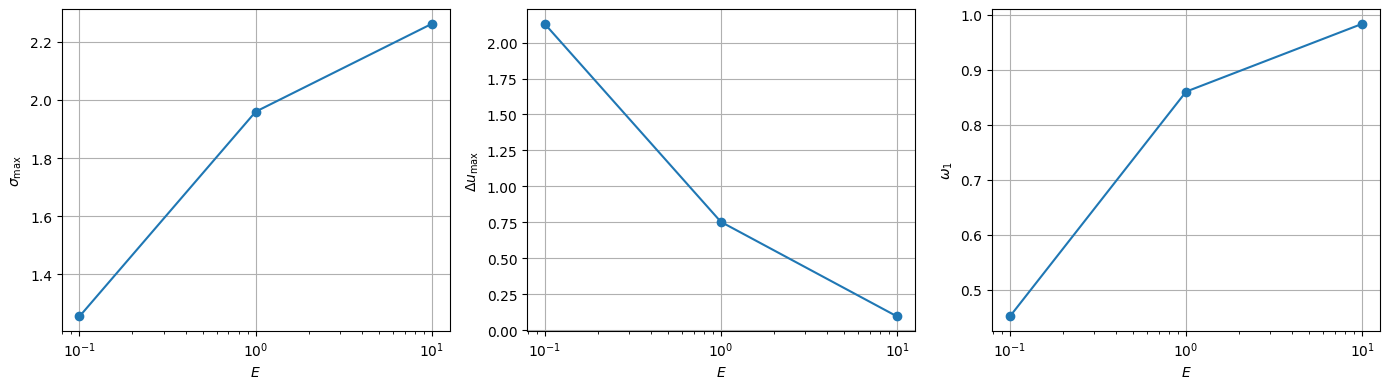

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(
    tabla_diseno["E"],
    tabla_diseno["sigma_max"],
    "o-"
)
axes[0].set_xlabel("$E$")
axes[0].set_ylabel("$\\sigma_{\\max}$")
axes[0].set_xscale("log")
axes[0].grid(True)

axes[1].plot(
    tabla_diseno["E"],
    tabla_diseno["Delta_u_max"],
    "o-"
)
axes[1].set_xlabel("$E$")
axes[1].set_ylabel("$\\Delta u_{\\max}$")
axes[1].set_xscale("log")
axes[1].grid(True)

axes[2].plot(
    tabla_diseno["E"],
    tabla_diseno["omega_1"],
    "o-"
)
axes[2].set_xlabel("$E$")
axes[2].set_ylabel("$\\omega_1$")
axes[2].set_xscale("log")
axes[2].grid(True)

plt.tight_layout()
plt.show()


## 3.6 Animaciones

Para visualizar el efecto de $E$, se puede animar el desplazamiento de la barra.

Las animaciones correspondientes a los tres casos se generan con el siguiente código. Se utilizan menos modos que en el cálculo de diseño únicamente para mantener la visualización limpia y rápida.


In [76]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

def mostrar_animacion_3(E, N=30, n_frames=120):

    gamma, mu, lam, alpha, omega = datos3[E]

    x = np.linspace(0, L3, 500)

    T1 = 2*np.pi/omega[0]
    times = np.linspace(0, 3*T1, n_frames)

    lamN = lam[:N]
    alphaN = alpha[:N]
    omegaN = omega[:N]

    # Modos espaciales
    U = np.cos(np.outer(lamN, x))

    # Crear figura
    fig, ax = plt.subplots(figsize=(7, 3.5))

    line, = ax.plot([], [], lw=2)

    ax.set_xlim(0, L3)
    ax.set_ylim(-0.1, 1.1)

    ax.set_xlabel("$x$")
    ax.set_ylabel("$u(x,t)$")
    ax.set_title(f"Vibración de la barra: $E={E:g}$")
    ax.grid(True)

    def init():
        line.set_data([], [])
        return line,

    def update(j):

        # Evolución temporal de cada modo
        T = np.cos(omegaN * times[j])

        # Solución modal:
        #
        # u(x,t) = sum(alpha_i T_i(t) U_i(x))
        #
        # Se calcula solamente para este instante.
        u = (alphaN * T) @ U

        line.set_data(x, u)

        ax.set_title(
            f"Vibración de la barra: $E={E:g}$, "
            f"$t={times[j]:.2f}$"
        )

        return line,

    animation = FuncAnimation(
        fig,
        update,
        frames=n_frames,
        init_func=init,
        blit=True
    )

    plt.close(fig)

    return HTML(animation.to_jshtml())


# Mostrar las tres animaciones directamente en el notebook

display(mostrar_animacion_3(0.1))
display(mostrar_animacion_3(1.0))
display(mostrar_animacion_3(10.0))

### Animaciones generadas

- $E=0.1$: `tarea4_punto3_E0p1_anim.gif`
- $E=1$: `tarea4_punto3_E1_anim.gif`
- $E=10$: `tarea4_punto3_E10_anim.gif`

La diferencia visual principal es que al aumentar $E$ disminuye la deformación y aumenta la rapidez de oscilación.


## 3.7 Conclusión de diseño

El parámetro de diseño principal es el módulo de Young $E$.

Para $E=0.1$ la pieza es más flexible: presenta el mayor cambio de longitud y la menor frecuencia natural.

Para $E=10$ la pieza es más rígida: presenta el menor cambio de longitud y la mayor frecuencia natural.

Por lo tanto, si el criterio principal es limitar la deformación, conviene aumentar $E$. Sin embargo, la selección de $E$ no debe hacerse únicamente con base en $\Delta u_{\max}$: también debe verificarse el esfuerzo máximo admisible del material.

En consecuencia, el diseño debe buscar un compromiso entre

$$
\boxed{
\sigma_{\max}\leq\sigma_{\mathrm{adm}}
}
$$

y

$$
\boxed{
\Delta u_{\max}\leq\Delta u_{\mathrm{adm}}.
}
$$

La tabla permite comparar directamente estas restricciones para los tres materiales considerados.
